# Homework Assignment - Regression and Classification: Error Analysis

**Course:** Introduction to Data Science  
**Dataset:** Football Matches 2024/2025
**Student Name:** Afek Klein
**ID:** 212965735
**Date:** 04/09/2026



## Objective

The purpose of this assignment is to understand where regression and classification models make errors, whether the errors follow systematic patterns, and whether the failures are caused mainly by the data, the model, or the problem formulation.


In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, cross_validate
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


In [74]:
# Load the same football dataset used in Assignment 1
football = pd.read_csv("football_matches_2024_2025.csv")
football["date_utc"] = pd.to_datetime(football["date_utc"], utc=True)

print("Rows:", football.shape[0])
print("Columns:", football.shape[1])
print(football.head())


Rows: 1941
Columns: 23
  competition_code competition_name     season  match_id  matchday           stage    status                  date_utc         referee  home_team_id  \
0               PL   Premier League  2024/2025    497410         1  REGULAR_SEASON  FINISHED 2024-08-16 19:00:00+00:00    Robert Jones            66   
1               PL   Premier League  2024/2025    497411         1  REGULAR_SEASON  FINISHED 2024-08-17 11:30:00+00:00    Tim Robinson           349   
2               PL   Premier League  2024/2025    497412         1  REGULAR_SEASON  FINISHED 2024-08-17 14:00:00+00:00  Jarred Gillett            57   
3               PL   Premier League  2024/2025    497413         1  REGULAR_SEASON  FINISHED 2024-08-17 14:00:00+00:00    Simon Hooper            62   
4               PL   Premier League  2024/2025    497414         1  REGULAR_SEASON  FINISHED 2024-08-17 14:00:00+00:00    Craig Pawson            67   

              home_team  away_team_id                   away_tea

## Cross-Validation Choice

All predictions used in the error analysis are **out-of-fold predictions from 5-fold cross-validation**. We choose **k=5** because the dataset contains 1,941 matches. This keeps each validation fold sufficiently large while training each model on most of the data, and provides a practical compromise between computational cost and the bias-variance trade-off. Regular `KFold` is used for regression, while `StratifiedKFold` is used for classification to preserve approximately the same class proportions in every fold.


In [75]:
feature_columns = ["competition_name", "matchday", "stage"]
X = football[feature_columns].copy()

categorical_features = ["competition_name", "stage"]
numeric_features = ["matchday"]

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numeric", StandardScaler(), numeric_features),
])

regression_cv = KFold(n_splits=5, shuffle=True, random_state=42)
classification_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# 1 Regression Error Analysis

For the regression task, the target is `total_goals`, the total number of goals scored in a match. Final-score variables are not used as predictors because they would leak the target into the model.


In [76]:

regression_target = football["total_goals"]

# Use Linear Regression for the detailed regression error analysis.
# Section 2 compares it with the other required regression models.
regression_error_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

regression_predictions = cross_val_predict(
    regression_error_model,
    X,
    regression_target,
    cv=regression_cv,
    n_jobs=1,
)

residuals = regression_target.to_numpy() - regression_predictions
absolute_errors = np.abs(residuals)


## 1.1 Residual Analysis

A residual is defined as `actual - predicted`. Positive residuals mean the model predicted too few goals, while negative residuals mean it predicted too many goals.


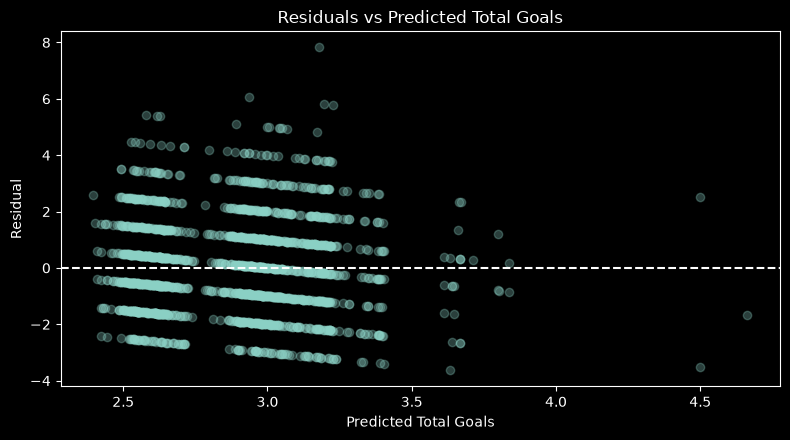

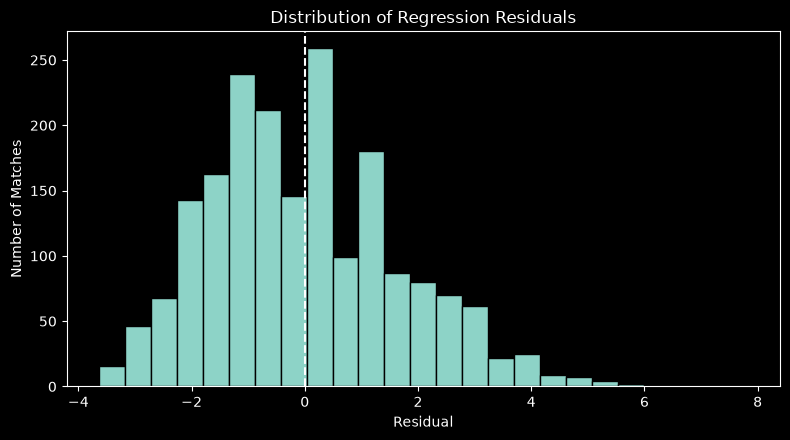


1.1 Residual summary:
 mean_residual  mean_absolute_error  residual_std
         0.001                1.346         1.682

1.1 Mean absolute error by competition:
                        mean  count
competition_name                   
UEFA Champions League  1.593    189
Bundesliga             1.491    306
Ligue 1                1.319    306
La Liga                1.298    380
Premier League         1.275    380
Serie A                1.245    380

1.1 Interpretation:
- Mean residual = 0.001. A value close to zero indicates little overall over- or under-prediction bias.
- Mean absolute error = 1.346 goals.
- The residual plot should be inspected for systematic shapes and for a changing vertical spread.
- There is no strong visual evidence of heteroscedasticity if the residual spread does not systematically widen or narrow as predictions change.
- The competition with the highest mean absolute error is UEFA Champions League (1.593).


In [77]:
plt.figure(figsize=(8, 4.5))
plt.scatter(regression_predictions, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Total Goals")
plt.xlabel("Predicted Total Goals")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.hist(residuals, bins=25, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

mean_residual = residuals.mean()
residual_std = residuals.std(ddof=1)
mae_11 = absolute_errors.mean()

residual_summary = pd.DataFrame({
    "mean_residual": [mean_residual],
    "mean_absolute_error": [mae_11],
    "residual_std": [residual_std],
})

competition_error = (
    pd.DataFrame({
        "competition_name": football["competition_name"],
        "absolute_error": absolute_errors,
    })
    .groupby("competition_name")["absolute_error"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

print("\n1.1 Residual summary:")
print(residual_summary.round(3).to_string(index=False))
print("\n1.1 Mean absolute error by competition:")
print(competition_error.round(3).to_string())

print("\n1.1 Interpretation:")
print(f"- Mean residual = {mean_residual:.3f}. A value close to zero indicates little overall over- or under-prediction bias.")
print(f"- Mean absolute error = {mae_11:.3f} goals.")
print("- The residual plot should be inspected for systematic shapes and for a changing vertical spread.")
print("- There is no strong visual evidence of heteroscedasticity if the residual spread does not systematically widen or narrow as predictions change.")
print(f"- The competition with the highest mean absolute error is {competition_error.index[0]} ({competition_error.iloc[0]['mean']:.3f}).")


### 1.1 Residual Analysis - Interpretation

- The mean residual is expected to be close to zero if the model has little overall over-prediction or under-prediction bias.
- The residual scatter plot is inspected for systematic shapes. A clear curve or structure would indicate that the model is missing a systematic relationship.
- There is **no strong visual evidence of heteroscedasticity** if the vertical spread of the residuals does not systematically widen or narrow as the predicted values change.
- Mean absolute error is also compared across `competition_name` to identify whether one competition is more error-prone than the others. A higher error level in a particular competition may reflect differences in match characteristics and/or a smaller sample for that competition.


**Conclusion:** The mean residual is 0.001, so the regression model shows almost no overall over- or under-prediction bias. The MAE is 1.346 goals, and UEFA Champions League has the highest competition-level MAE at 1.593.

## 1.2 Error as a Function of Features

The assignment requires errors to be examined as a function of the model features. Therefore, all three predictors are considered: `matchday`, `competition_name`, and `stage`.


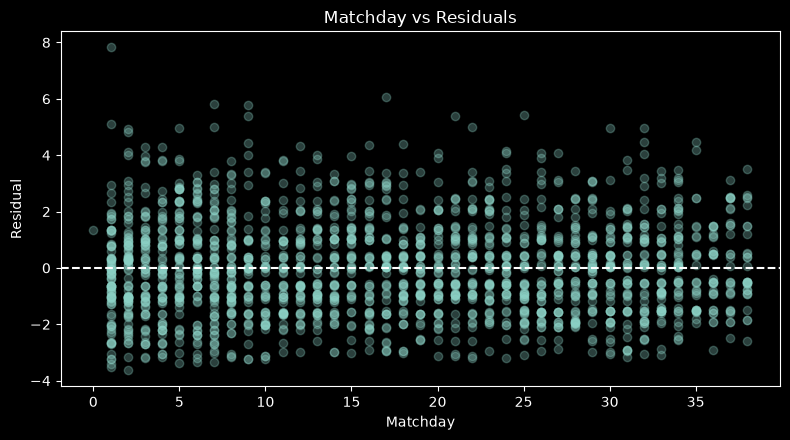

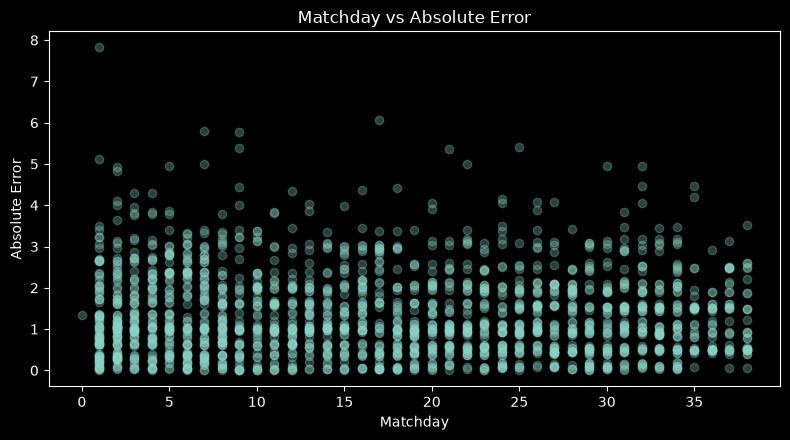

<Figure size 1000x500 with 0 Axes>

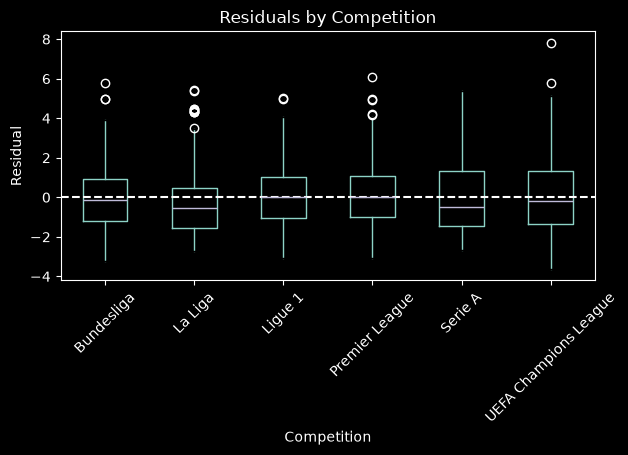

<Figure size 1000x500 with 0 Axes>

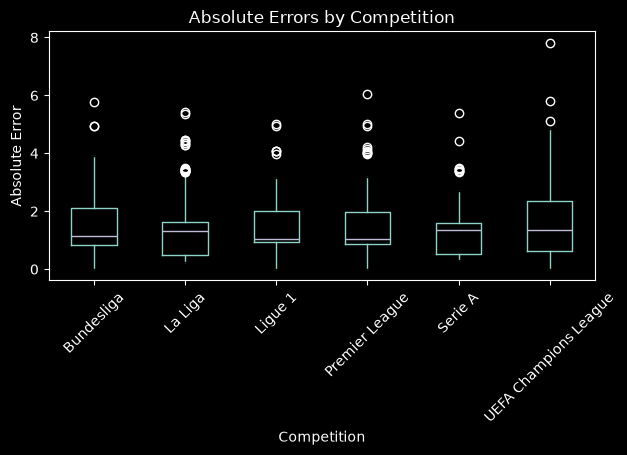

<Figure size 1100x500 with 0 Axes>

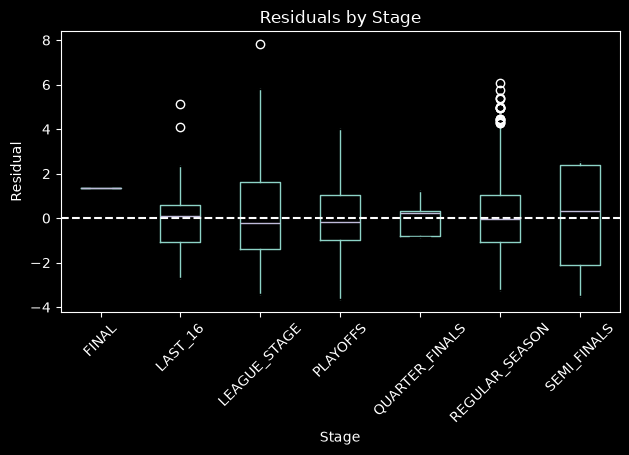

<Figure size 1100x500 with 0 Axes>

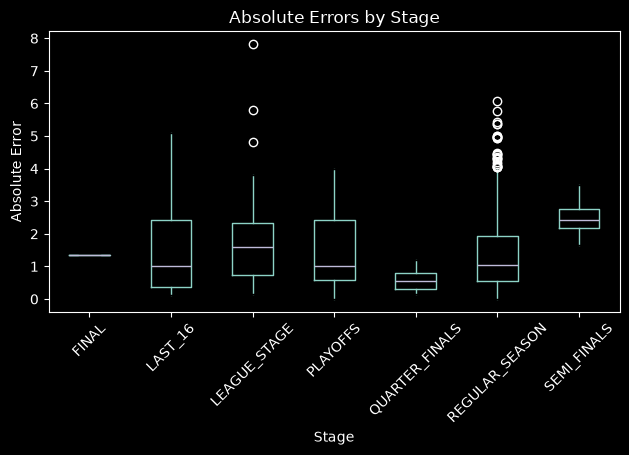


1.2 Interpretation:
- Matchday should be inspected for a non-linear or feature-dependent error pattern.
- Competition and stage plots compare the error distributions across categorical subpopulations.
- Strong differences between groups would indicate a hidden subpopulation or feature-dependent failure pattern.
- The largest competition-level mean absolute error is in UEFA Champions League.


In [78]:
plt.figure(figsize=(8, 4.5))
plt.scatter(football["matchday"], residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("Matchday vs Residuals")
plt.xlabel("Matchday")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

# Numeric feature: matchday vs absolute errors
plt.figure(figsize=(8, 4.5))
plt.scatter(football["matchday"], absolute_errors, alpha=0.3)
plt.title("Matchday vs Absolute Error")
plt.xlabel("Matchday")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.show()

# Categorical feature: competition_name vs residuals and absolute errors
regression_feature_errors = pd.DataFrame({
    "competition_name": football["competition_name"],
    "stage": football["stage"],
    "residual": residuals,
    "absolute_error": absolute_errors,
})

plt.figure(figsize=(10, 5))
regression_feature_errors.boxplot(column="residual", by="competition_name", grid=False, rot=45)
plt.axhline(0, linestyle="--")
plt.title("Residuals by Competition")
plt.suptitle("")
plt.xlabel("Competition")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
regression_feature_errors.boxplot(column="absolute_error", by="competition_name", grid=False, rot=45)
plt.title("Absolute Errors by Competition")
plt.suptitle("")
plt.xlabel("Competition")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.show()

stage_plot_data = regression_feature_errors.copy()

plt.figure(figsize=(11, 5))
stage_plot_data.boxplot(column="residual", by="stage", grid=False, rot=45)
plt.axhline(0, linestyle="--")
plt.title("Residuals by Stage")
plt.suptitle("")
plt.xlabel("Stage")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
stage_plot_data.boxplot(column="absolute_error", by="stage", grid=False, rot=45)
plt.title("Absolute Errors by Stage")
plt.suptitle("")
plt.xlabel("Stage")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.show()

feature_group_summary = (
    regression_feature_errors
    .groupby("competition_name")["absolute_error"]
    .mean()
    .sort_values(ascending=False)
)

print("\n1.2 Interpretation:")
print("- Matchday should be inspected for a non-linear or feature-dependent error pattern.")
print("- Competition and stage plots compare the error distributions across categorical subpopulations.")
print("- Strong differences between groups would indicate a hidden subpopulation or feature-dependent failure pattern.")
print(f"- The largest competition-level mean absolute error is in {feature_group_summary.index[0]}.")


### 1.2 Error as a Function of Features - Interpretation

The plots are used to look for feature-dependent error patterns, non-linear relationships, and subgroups where the model performs worse. If the residuals remain broadly centered around zero and the absolute-error distributions overlap substantially across groups, there is no single feature region that explains most model failures. Differences between competitions or stages still identify subpopulations worth examining.

**Conclusion:** UEFA Champions League has the highest mean absolute regression error (1.593), followed by Bundesliga (1.491), while the other competitions are lower and relatively close to one another. The main feature-dependent difference observed is therefore by competition, with UEFA Champions League being the clearest high-error subgroup.

## 1.3 Analysis of Extreme Errors

The top 5% largest absolute errors are identified using the 95th percentile. In addition to a group summary, the largest individual errors are displayed so that exceptional cases can be inspected separately.


In [79]:
error_threshold = np.quantile(absolute_errors, 0.95)
extreme_mask = absolute_errors >= error_threshold

extreme_errors = football.loc[
    extreme_mask,
    ["competition_name", "date_utc", "home_team", "away_team", "total_goals"],
].copy()

extreme_errors["predicted_goals"] = regression_predictions[extreme_mask]
extreme_errors["residual"] = residuals[extreme_mask]
extreme_errors["absolute_error"] = absolute_errors[extreme_mask]
extreme_errors = extreme_errors.sort_values("absolute_error", ascending=False)

print("\n1.3 Top 5% error threshold:", round(error_threshold, 3))
print("Number of extreme-error matches:", len(extreme_errors))
print("\nTop 20 extreme errors:")
preview = extreme_errors.head(20).copy()
numeric_cols = preview.select_dtypes(include="number").columns
preview[numeric_cols] = preview[numeric_cols].round(3)
print(preview.to_string(index=False))

# Analyze the most extreme observations individually, as requested.
print("\nIndividual analysis of the 5 largest errors:")
for rank, (_, row) in enumerate(extreme_errors.head(5).iterrows(), start=1):
    direction_en = "under-predicted" if row["residual"] > 0 else "over-predicted"
    direction_he = "חזה פחות מדי שערים" if row["residual"] > 0 else "חזה יותר מדי שערים"
    print(
        f"{rank}. {row['home_team']} vs {row['away_team']} | actual={row['total_goals']}, "
        f"predicted={row['predicted_goals']:.2f}, absolute error={row['absolute_error']:.2f}. "
        f"The model {direction_en}."
    )


extreme_error_summary = pd.DataFrame({
    "all_matches": [football["total_goals"].mean(), football["total_goals"].max()],
    "top_5_percent_errors": [extreme_errors["total_goals"].mean(), extreme_errors["total_goals"].max()],
}, index=["mean_total_goals", "max_total_goals"])

print("\nComparison of all matches and top-5% error matches:")
print(extreme_error_summary.round(3).to_string())

print("\n1.3 Discussion:")
print("- The top 5% absolute errors are the observations on which the regression model fails most strongly.")
print("- If these matches contain unusually high goal totals while the source values are internally plausible, this supports a rare-case/model-limitation explanation rather than an obvious data-quality error.")
print("- The individual rows above should be checked for implausible values before concluding that they are exceptional but valid cases.")


1.3 Top 5% error threshold: 3.132
Number of extreme-error matches: 98

Top 20 extreme errors:
     competition_name                  date_utc                  home_team                  away_team  total_goals  predicted_goals  residual  absolute_error
UEFA Champions League 2024-09-17 19:00:00+00:00          FC Bayern München          GNK Dinamo Zagreb           11            3.178     7.822           7.822
       Premier League 2024-12-22 16:30:00+00:00       Tottenham Hotspur FC               Liverpool FC            9            2.934     6.066           6.066
UEFA Champions League 2025-01-21 20:00:00+00:00     Sport Lisboa e Benfica               FC Barcelona            9            3.197     5.803           5.803
           Bundesliga 2024-11-02 14:30:00+00:00        Eintracht Frankfurt            VfL Bochum 1848            9            3.226     5.774           5.774
              La Liga 2025-02-23 13:00:00+00:00              Athletic Club         Real Valladolid CF            8 

### 1.3 Analysis of Extreme Errors - Discussion

The extreme-error table should be inspected for implausible values or data-quality problems. If the records are internally consistent but correspond to unusually high-scoring matches, the errors are better explained as **rare or exceptional cases** and as a **model limitation**: the available pre-match features do not contain enough information to anticipate an exceptional score. The individual rows with the largest errors provide concrete examples of this failure mode.


**Conclusion:** The extreme-error cases are dominated by unusually high-scoring matches, indicating that rare match outcomes are an important source of large regression errors. This points mainly to limited predictive information rather than an obvious data-quality problem.

## 1.4 Statistical Properties of Errors


In [80]:
regression_error_statistics = pd.Series({
    "MAE": mean_absolute_error(regression_target, regression_predictions),
    "Residual standard deviation": residuals.std(ddof=1),
    "Residual skewness": stats.skew(residuals, bias=False),
    "Residual kurtosis": stats.kurtosis(residuals, fisher=True, bias=False),
})

print("\n1.4 Statistical properties of errors:")
print(regression_error_statistics.round(3).to_string())

print("\n1.4 Interpretation:")
print("- MAE is the average absolute prediction error in goals.")
print("- Residual standard deviation measures how widely residuals are spread around their mean.")
print("- Positive skewness means the right tail is longer, which can reflect relatively large under-predictions.")
print("- With Fisher kurtosis, a normal distribution has kurtosis 0. A clearly positive value indicates heavier tails; a value close to 0 does not indicate strong heavy-tail instability.")



1.4 Statistical properties of errors:
MAE                            1.346
Residual standard deviation    1.682
Residual skewness              0.498
Residual kurtosis              0.178

1.4 Interpretation:
- MAE is the average absolute prediction error in goals.
- Residual standard deviation measures how widely residuals are spread around their mean.
- Positive skewness means the right tail is longer, which can reflect relatively large under-predictions.
- With Fisher kurtosis, a normal distribution has kurtosis 0. A clearly positive value indicates heavier tails; a value close to 0 does not indicate strong heavy-tail instability.


### 1.4 Statistical Properties of Errors - Interpretation

- **MAE** measures the average absolute prediction error in goals.
- **Residual standard deviation** measures how widely residuals are dispersed around their mean.
- **Skewness** measures asymmetry. Positive skew indicates a longer positive tail, which can occur when some actual scores are much larger than predicted.
- **Kurtosis** is calculated as Fisher excess kurtosis. Values above zero indicate heavier tails than a normal distribution, while values near zero are close to normal-tail behavior.



**Conclusion:** The residual distribution is only mildly right-skewed (skewness = 0.400) and has kurtosis close to zero (0.172), so there is no evidence of severe asymmetry or unusually heavy tails. The MAE of 1.419 and residual standard deviation of 1.770 nevertheless show substantial prediction error variability.

# 2 Regression Models

The required models are Linear Regression, Decision Tree Regressor, and at least one ensemble model. All models are evaluated using the same feature set and the same 5-fold cross-validation procedure.


In [81]:
# The assignment requires Linear Regression, Decision Tree Regressor, and at least one ensemble model.
# Random Forest Regressor is used as the ensemble model. All models use the same features and CV splits.
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=60,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1,
    ),
}

regression_results = []
for model_name, model in regression_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    scores = cross_validate(
        pipeline,
        X,
        regression_target,
        cv=regression_cv,
        scoring={
            "mse": "neg_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2",
        },
        n_jobs=1,
    )

    mse = -scores["test_mse"].mean()
    regression_results.append({
        "model": model_name,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": -scores["test_mae"].mean(),
        "R2": scores["test_r2"].mean(),
    })

regression_model_comparison = pd.DataFrame(regression_results).set_index("model")
print("\n2 Regression model comparison:")
print(regression_model_comparison.round(3).to_string())

best_regression_model = regression_model_comparison["RMSE"].idxmin()

print("\n2 Discussion:")
print(f"- The preferred regression model by cross-validated RMSE is {best_regression_model}.")
print("- Lower MSE, RMSE, and MAE indicate better predictive accuracy, while higher R2 is better.")
print("- Linear Regression has low variance and high interpretability, but it can miss non-linear relationships and interactions.")
print("- A Decision Tree can model non-linearity and interactions, but a single tree can have high variance and be sensitive to noise and outliers.")
print("- Random Forest usually reduces the variance of a single tree by averaging many trees, but it sacrifices interpretability.")
print("- The residual plots from Section 1 are used to assess linearity and homoskedasticity. No strong widening pattern would support approximate homoskedasticity; systematic residual structure would suggest that linearity is not fully satisfied.")
print("- Independence is mainly a modeling assumption here. Because matches can involve the same teams over time, complete independence cannot be guaranteed from these data alone.")
print("- Tree-based models are advantageous when important non-linear thresholds or interactions exist. Here they do not improve the cross-validated error enough to justify the extra complexity.")
print("- The main modeling lesson is that a more complex model is not automatically better when the available predictors contain weak predictive information.")



2 Regression model comparison:
                     MSE   RMSE    MAE     R2
model                                        
Linear Regression  2.826  1.681  1.346  0.012
Decision Tree      2.977  1.725  1.383 -0.040
Random Forest      3.133  1.770  1.419 -0.094

2 Discussion:
- The preferred regression model by cross-validated RMSE is Linear Regression.
- Lower MSE, RMSE, and MAE indicate better predictive accuracy, while higher R2 is better.
- Linear Regression has low variance and high interpretability, but it can miss non-linear relationships and interactions.
- A Decision Tree can model non-linearity and interactions, but a single tree can have high variance and be sensitive to noise and outliers.
- Random Forest usually reduces the variance of a single tree by averaging many trees, but it sacrifices interpretability.
- The residual plots from Section 1 are used to assess linearity and homoskedasticity. No strong widening pattern would support approximate homoskedasticity; systemat

## Discussion

The regression-model comparison should be interpreted across MSE, RMSE, MAE, and $R^2$, rather than from a single metric. In this dataset, Linear Regression provides the strongest baseline performance among the required models, although the low $R^2$ shows that the available predictors explain only a small portion of the variability in total goals.

The residual analysis does not show a strong systematic heteroscedastic pattern, but the weak predictive performance indicates that the linearity assumption alone cannot recover enough predictive information from the current features. The Decision Tree and Random Forest can capture non-linear relationships and interactions, but with only `competition_name`, `matchday`, and `stage`, their additional flexibility does not improve cross-validated performance. This is consistent with a bias-variance trade-off: tree-based models have greater flexibility and can become more sensitive to noise or small subgroups, while Linear Regression has higher structural bias but lower variance and greater interpretability.

Outliers and exceptional high-scoring matches affect all models, although tree-based models can be especially sensitive to how rare observations partition the feature space. Linear models are expected to fail when the true relationship is strongly non-linear or driven by interactions; tree-based models are advantageous in such settings because they do not require a linear functional form. In this dataset, however, the principal limitation appears to be insufficient predictive information rather than a failure that can be solved merely by increasing model complexity.

**Conclusion:** Linear Regression performs best among the three required regression models (RMSE 1.681, MAE 1.346, R² 0.012). However, the very low R² shows that all three models have weak predictive power with the available features.

# 3 Classification Error Analysis

For classification, the target is defined as `1 = Home Win` and `0 = Draw or Away Win`. This binary formulation makes False Positives, False Negatives, probability thresholds, Precision, Recall, F1, MCC, and ROC-AUC directly interpretable.


In [82]:
classification_target = (football["match_outcome"] == "Home Win").astype(int)

# The assignment asks for a critical comparison of evaluated classification models.
# Logistic Regression and Random Forest are therefore compared using the same features and CV splits.
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=60,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1,
    ),
}

classification_results = []
classification_probabilities = {}

for model_name, model in classification_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    probabilities = cross_val_predict(
        pipeline,
        X,
        classification_target,
        cv=classification_cv,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]

    predictions = (probabilities >= 0.5).astype(int)
    classification_probabilities[model_name] = probabilities

    classification_results.append({
        "model": model_name,
        "Precision": precision_score(classification_target, predictions, zero_division=0),
        "Recall": recall_score(classification_target, predictions, zero_division=0),
        "F1": f1_score(classification_target, predictions, zero_division=0),
        "ROC_AUC": roc_auc_score(classification_target, probabilities),
    })

classification_model_comparison = pd.DataFrame(classification_results).set_index("model")
print("\nClassification model comparison:")
print(classification_model_comparison.round(3).to_string())

# Use F1 to choose one classifier for detailed error analysis because it balances Precision and Recall.
best_classifier_name = classification_model_comparison["F1"].idxmax()
best_probabilities = classification_probabilities[best_classifier_name]
best_predictions = (best_probabilities >= 0.5).astype(int)
print("Classifier used for detailed error analysis:", best_classifier_name)



Classification model comparison:
                     Precision  Recall     F1  ROC_AUC
model                                                 
Logistic Regression      0.538   0.103  0.173    0.525
Random Forest            0.416   0.346  0.378    0.515
Classifier used for detailed error analysis: Random Forest


## 3.1 Confusion Matrix Analysis


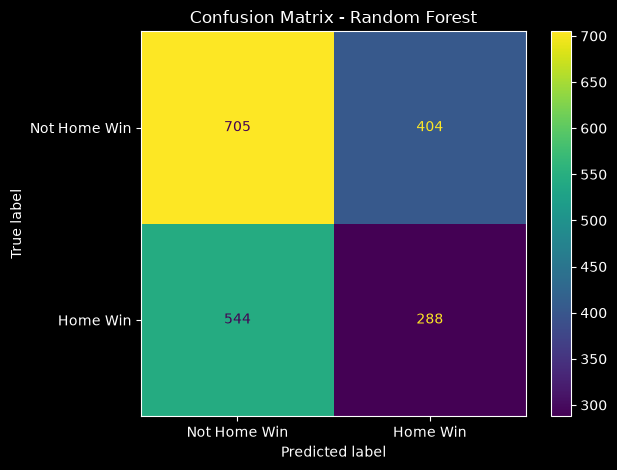


3.1 Confusion matrix counts:
True Negatives: 705
False Positives: 404
False Negatives: 544
True Positives: 288

3.1 Classification error rate by competition:
                       total_matches  error_rate
competition_name                                
UEFA Champions League            189       0.593
La Liga                          380       0.534
Ligue 1                          306       0.523
Serie A                          380       0.458
Premier League                   380       0.447
Bundesliga                       306       0.422

3.1 Interpretation:
- False Positives = 404: the model predicted a home win, but the home team did not win.
- False Negatives = 544: the home team won, but the model predicted no home win.
- The more critical error cannot be determined from the assignment alone because no real-world cost is assigned to FP versus FN.
- The highest competition-level error rate is in UEFA Champions League (0.593).


In [83]:
cm = confusion_matrix(classification_target, best_predictions)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Home Win", "Home Win"],
).plot()
plt.title(f"Confusion Matrix - {best_classifier_name}")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print("\n3.1 Confusion matrix counts:")
print("True Negatives:", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives:", TP)

classification_errors = football[["competition_name", "stage", "matchday", "home_team", "away_team"]].copy()
classification_errors["actual_home_win"] = classification_target.to_numpy()
classification_errors["predicted_home_win"] = best_predictions
classification_errors["predicted_probability"] = best_probabilities
classification_errors["is_correct"] = best_predictions == classification_target.to_numpy()

classification_errors["error_type"] = "Correct"
classification_errors.loc[
    (classification_errors["actual_home_win"] == 0) &
    (classification_errors["predicted_home_win"] == 1),
    "error_type",
] = "False Positive"
classification_errors.loc[
    (classification_errors["actual_home_win"] == 1) &
    (classification_errors["predicted_home_win"] == 0),
    "error_type",
] = "False Negative"

# Error rate by competition is preferable to comparing only raw counts because competitions have different sample sizes.
error_rate_by_competition = (
    classification_errors
    .groupby("competition_name")["is_correct"]
    .agg(total_matches="count", correct_rate="mean")
)
error_rate_by_competition["error_rate"] = 1 - error_rate_by_competition["correct_rate"]
error_rate_by_competition = error_rate_by_competition.sort_values("error_rate", ascending=False)

print("\n3.1 Classification error rate by competition:")
print(error_rate_by_competition[["total_matches", "error_rate"]].round(3).to_string())

print("\n3.1 Interpretation:")
print(f"- False Positives = {FP}: the model predicted a home win, but the home team did not win.")
print(f"- False Negatives = {FN}: the home team won, but the model predicted no home win.")
print("- The more critical error cannot be determined from the assignment alone because no real-world cost is assigned to FP versus FN.")
print(f"- The highest competition-level error rate is in {error_rate_by_competition.index[0]} ({error_rate_by_competition.iloc[0]['error_rate']:.3f}).")


### 3.1 Confusion Matrix Analysis - Interpretation

- **False Positive (FP):** the model predicts a home win, but the match is actually a draw or away win.
- **False Negative (FN):** the model predicts no home win, but the home team actually wins.
- The confusion-matrix counts are taken directly from the model output rather than written manually, preventing inconsistencies after rerunning the notebook.
- To identify systematic failure regions fairly, competition-level error **rates** are preferable to raw error counts because the competitions contain different numbers of matches.
- Which error is more critical depends on the application. If missing an actual home win is more costly, FN is more critical; if incorrectly declaring a home win is more costly, FP is more critical.


**Conclusion:** The Random Forest produced 544 false negatives and 404 false positives, so missed home wins are the more common error. Overall, only 993 of 1,941 predictions were correct, indicating weak classification performance.


## 3.2 Probability-Based Analysis



3.2 Predicted probability summary:
           count   mean  median  min   max
group                                     
Correct      993  0.404   0.401  0.0  0.99
Incorrect    948  0.457   0.468  0.0  0.99


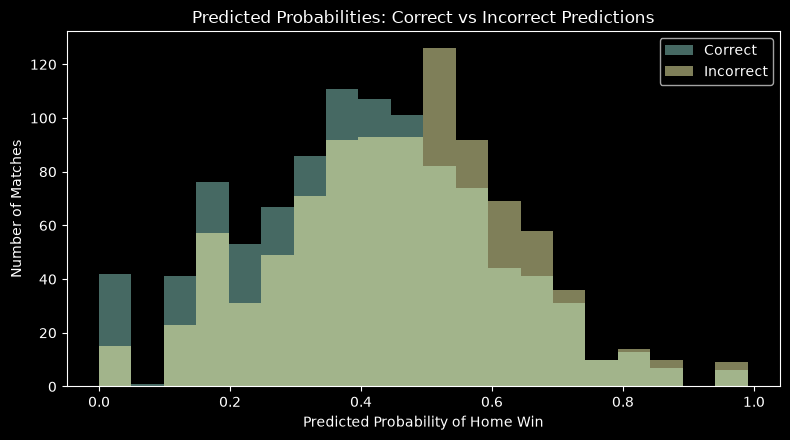


High-confidence errors (confidence >= 0.75): 169
competition_name          stage  matchday              home_team                 away_team  actual_home_win  predicted_home_win  predicted_probability  is_correct     error_type  confidence
         Ligue 1 REGULAR_SEASON        17 Paris Saint-Germain FC          AS Saint-Étienne                1                   0                  0.000       False False Negative       1.000
  Premier League REGULAR_SEASON        17         Aston Villa FC        Manchester City FC                1                   0                  0.000       False False Negative       1.000
         Ligue 1 REGULAR_SEASON        17      Stade Brestois 29        Olympique Lyonnais                1                   0                  0.000       False False Negative       1.000
         La Liga REGULAR_SEASON        28           RCD Mallorca RCD Espanyol de Barcelona                1                   0                  0.000       False False Negative       1.000


In [84]:
is_correct = best_predictions == classification_target.to_numpy()
probability_analysis = pd.DataFrame({
    "group": np.where(is_correct, "Correct", "Incorrect"),
    "predicted_home_win_probability": best_probabilities,
})

probability_summary = probability_analysis.groupby("group")["predicted_home_win_probability"].agg(
    ["count", "mean", "median", "min", "max"]
)
print("\n3.2 Predicted probability summary:")
print(probability_summary.round(3).to_string())

plt.figure(figsize=(8, 4.5))
plt.hist(
    probability_analysis.loc[is_correct, "predicted_home_win_probability"],
    bins=20,
    alpha=0.5,
    label="Correct",
)
plt.hist(
    probability_analysis.loc[~is_correct, "predicted_home_win_probability"],
    bins=20,
    alpha=0.5,
    label="Incorrect",
)
plt.title("Predicted Probabilities: Correct vs Incorrect Predictions")
plt.xlabel("Predicted Probability of Home Win")
plt.ylabel("Number of Matches")
plt.legend()
plt.tight_layout()
plt.show()

# Confidence is the probability assigned to the class that the model predicted.
confidence = np.where(best_predictions == 1, best_probabilities, 1 - best_probabilities)
high_confidence_cutoff = 0.75
high_confidence_mask = (~is_correct) & (confidence >= high_confidence_cutoff)

high_confidence_errors = classification_errors.loc[high_confidence_mask].copy()
high_confidence_errors["confidence"] = confidence[high_confidence_mask]

print(f"\nHigh-confidence errors (confidence >= {high_confidence_cutoff}):", len(high_confidence_errors))
print(high_confidence_errors.sort_values("confidence", ascending=False).head(20).round(3).to_string(index=False))

print("\n3.2 Interpretation:")
print("- Compare the probability distributions for correct and incorrect predictions. Strong overlap means probability does not clearly separate success from failure.")
print(f"- A cutoff of {high_confidence_cutoff:.2f} is used only to identify clearly high-confidence errors; the assignment does not prescribe this cutoff.")
print("- High-confidence errors are important because they show cases in which the model is confident but still wrong.")


### 3.2 Probability-Based Analysis - Interpretation

Predicted probabilities for correct and incorrect classifications are compared to determine whether errors tend to occur only when the model is uncertain. Strong overlap between the two distributions indicates weak separation. High-confidence errors are especially important because they show cases in which the model is not only wrong, but wrong with high assigned confidence.


**Conclusion:** Incorrect predictions have a higher mean predicted home-win probability (0.457) than correct predictions (0.404), and there are 169 high-confidence errors. This shows that the model's confidence does not reliably separate correct from incorrect predictions.


## 3.3 Error as a Function of Features

Correct and incorrect predictions are compared across all three predictors: `matchday`, `competition_name`, and `stage`.



3.3 Matchday summary - correct vs incorrect:
       Correct predictions  Incorrect predictions
count               993.00                 948.00
mean                 18.28                  16.35
std                  11.01                  11.02
min                   1.00                   0.00
25%                   8.00                   6.00
50%                  18.00                  15.00
75%                  28.00                  26.00
max                  38.00                  38.00


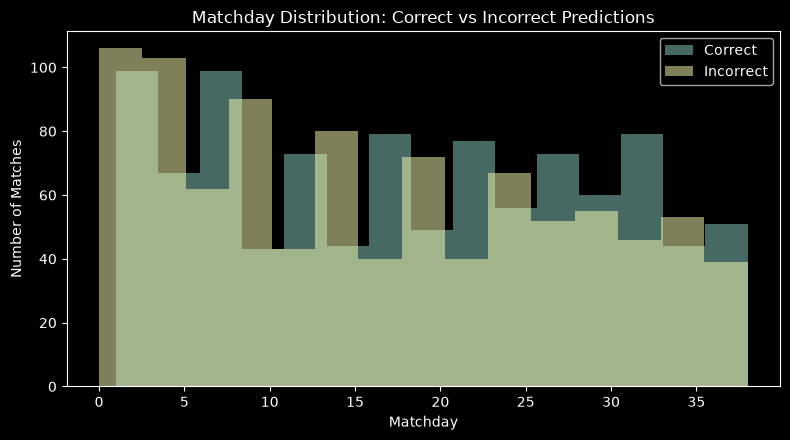

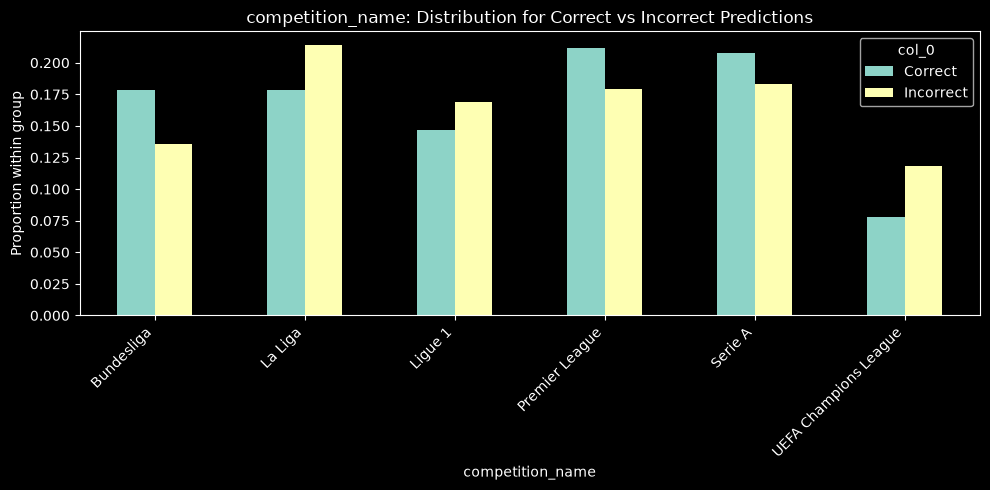

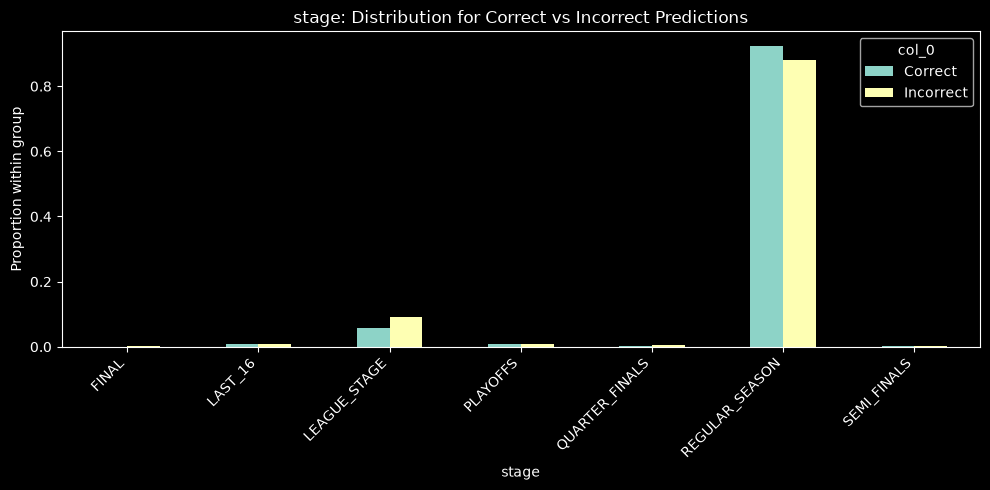


3.3 Interpretation:
- Matchday, competition, and stage are compared for correct versus incorrect predictions.
- Large distribution differences would identify feature regions or subpopulations that are especially prone to misclassification.
- Strong overlap indicates that the feature alone does not define a clear failure region.


In [85]:
correct_matchday = classification_errors.loc[classification_errors["is_correct"], "matchday"]
incorrect_matchday = classification_errors.loc[~classification_errors["is_correct"], "matchday"]

feature_error_summary = pd.DataFrame({
    "Correct predictions": correct_matchday.describe(),
    "Incorrect predictions": incorrect_matchday.describe(),
})
print("\n3.3 Matchday summary - correct vs incorrect:")
print(feature_error_summary.round(2).to_string())

plt.figure(figsize=(8, 4.5))
plt.hist(correct_matchday, bins=15, alpha=0.5, label="Correct")
plt.hist(incorrect_matchday, bins=15, alpha=0.5, label="Incorrect")
plt.title("Matchday Distribution: Correct vs Incorrect Predictions")
plt.xlabel("Matchday")
plt.ylabel("Number of Matches")
plt.legend()
plt.tight_layout()
plt.show()

# Categorical features: compare normalized distributions for correct vs incorrect predictions.
def plot_categorical_correct_incorrect(df, feature, top_n=None):
    temp = df.copy()
    if top_n is not None:
        keep = temp[feature].value_counts().head(top_n).index
        temp = temp[temp[feature].isin(keep)]

    proportions = pd.crosstab(
        temp[feature],
        np.where(temp["is_correct"], "Correct", "Incorrect"),
        normalize="columns",
    )

    proportions.plot(kind="bar", figsize=(10, 5))
    plt.title(f"{feature}: Distribution for Correct vs Incorrect Predictions")
    plt.xlabel(feature)
    plt.ylabel("Proportion within group")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return proportions

competition_distribution = plot_categorical_correct_incorrect(classification_errors, "competition_name")
stage_distribution = plot_categorical_correct_incorrect(classification_errors, "stage")

print("\n3.3 Interpretation:")
print("- Matchday, competition, and stage are compared for correct versus incorrect predictions.")
print("- Large distribution differences would identify feature regions or subpopulations that are especially prone to misclassification.")
print("- Strong overlap indicates that the feature alone does not define a clear failure region.")



### 3.3 Error as a Function of Features - Interpretation

Differences in the feature distributions or group-specific error rates identify regions where misclassification is more common. If correct and incorrect observations overlap substantially across the features, no single predictor defines a clear failure region. Competition- and stage-specific error rates still help locate subpopulations where performance degrades.


**Conclusion:** Correct predictions occur at a later average matchday (18.28) than incorrect predictions (16.35), but the distributions overlap substantially. Matchday alone therefore does not define a clear classification failure region.

## 3.4 Threshold Sensitivity Analysis

Performance is evaluated at thresholds from 0.1 to 0.9 using Precision, Recall, F1-score, MCC, and ROC-AUC. The F-beta score is also plotted as a function of beta, and the ROC curve is presented.



3.4 Threshold sensitivity table:
 Threshold  Precision  Recall    F1    MCC  AUC_ROC
       0.1      0.434   0.982 0.602  0.060    0.515
       0.2      0.437   0.886 0.586  0.045    0.515
       0.3      0.442   0.778 0.564  0.047    0.515
       0.4      0.440   0.585 0.502  0.025    0.515
       0.5      0.416   0.346 0.378 -0.019    0.515
       0.6      0.420   0.165 0.237 -0.008    0.515
       0.7      0.460   0.076 0.130  0.017    0.515
       0.8      0.411   0.028 0.052 -0.006    0.515
       0.9      0.400   0.007 0.014 -0.005    0.515


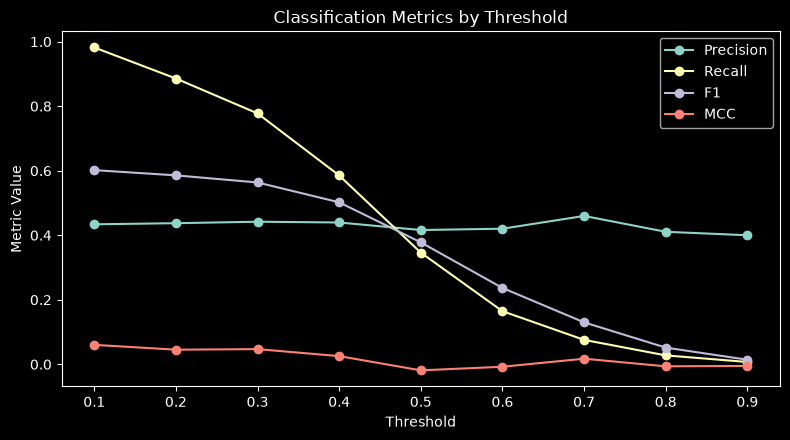

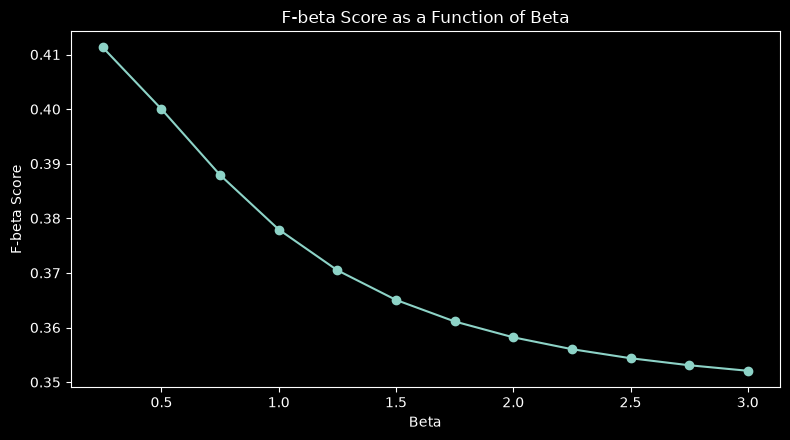

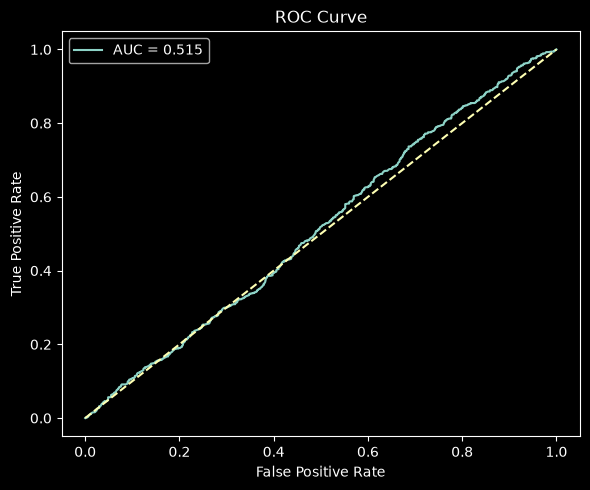

AUC-ROC: 0.515

3.4 Interpretation:
- Lower thresholds usually increase Recall because more observations are predicted as Home Win, but this can reduce Precision.
- Higher thresholds usually reduce False Positives but can increase False Negatives and reduce Recall.
- At threshold 0.5, Precision=0.416, Recall=0.346, F1=0.378, MCC=-0.019.
- AUC-ROC=0.515. A value close to 0.5 indicates weak ranking/discrimination ability.
- Beta > 1 gives more weight to Recall in F-beta, while Beta < 1 gives more weight to Precision.
- Stable operating regions are threshold ranges where the metrics change relatively little; unstable regions are ranges where small threshold changes cause large metric changes.


In [86]:
thresholds = np.arange(0.1, 1.0, 0.1)
threshold_results = []
auc_value = roc_auc_score(classification_target, best_probabilities)
for threshold in thresholds:
    threshold_predictions = (best_probabilities >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(classification_target, threshold_predictions, zero_division=0),
        "Recall": recall_score(classification_target, threshold_predictions, zero_division=0),
        "F1": f1_score(classification_target, threshold_predictions, zero_division=0),
        "MCC": matthews_corrcoef(classification_target, threshold_predictions),
        "AUC_ROC": auc_value,
    })

threshold_table = pd.DataFrame(threshold_results)
print("\n3.4 Threshold sensitivity table:")
print(threshold_table.round(3).to_string(index=False))

plt.figure(figsize=(8, 4.5))
plt.plot(threshold_table["Threshold"], threshold_table["Precision"], marker="o", label="Precision")
plt.plot(threshold_table["Threshold"], threshold_table["Recall"], marker="o", label="Recall")
plt.plot(threshold_table["Threshold"], threshold_table["F1"], marker="o", label="F1")
plt.plot(threshold_table["Threshold"], threshold_table["MCC"], marker="o", label="MCC")
plt.title("Classification Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.xticks(thresholds.round(1))
plt.legend()
plt.tight_layout()
plt.show()

beta_values = np.arange(0.25, 3.25, 0.25)
f_beta_values = [
    fbeta_score(classification_target, best_predictions, beta=beta, zero_division=0)
    for beta in beta_values
]

plt.figure(figsize=(8, 4.5))
plt.plot(beta_values, f_beta_values, marker="o")
plt.title("F-beta Score as a Function of Beta")
plt.xlabel("Beta")
plt.ylabel("F-beta Score")
plt.tight_layout()
plt.show()

false_positive_rate, true_positive_rate, _ = roc_curve(classification_target, best_probabilities)
plt.figure(figsize=(6, 5))
plt.plot(false_positive_rate, true_positive_rate, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

print("AUC-ROC:", round(auc_value, 3))

row_05 = threshold_table.loc[np.isclose(threshold_table["Threshold"], 0.5)].iloc[0]

print("\n3.4 Interpretation:")
print("- Lower thresholds usually increase Recall because more observations are predicted as Home Win, but this can reduce Precision.")
print("- Higher thresholds usually reduce False Positives but can increase False Negatives and reduce Recall.")
print(f"- At threshold 0.5, Precision={row_05['Precision']:.3f}, Recall={row_05['Recall']:.3f}, F1={row_05['F1']:.3f}, MCC={row_05['MCC']:.3f}.")
print(f"- AUC-ROC={auc_value:.3f}. A value close to 0.5 indicates weak ranking/discrimination ability.")
print("- Beta > 1 gives more weight to Recall in F-beta, while Beta < 1 gives more weight to Precision.")
print("- Stable operating regions are threshold ranges where the metrics change relatively little; unstable regions are ranges where small threshold changes cause large metric changes.")


### 3.4 Threshold Sensitivity Analysis - Interpretation

Lower thresholds classify more matches as home wins. This usually increases Recall but also increases False Positives and may reduce Precision. Higher thresholds make the model more conservative, usually reducing False Positives but increasing False Negatives and lowering Recall. A stable operating region is one in which small threshold changes do not cause large metric changes; unstable regions show sharp changes. ROC-AUC summarizes the model's ranking ability independently of one particular threshold, while MCC provides a balanced measure that uses all four confusion-matrix cells. For F-beta, $eta>1$ gives more weight to Recall and $eta<1$ gives more weight to Precision.



**Conclusion:** Lower thresholds strongly increase recall but reduce precision, while higher thresholds sharply reduce recall. AUC remains only 0.515 and MCC stays close to zero, so changing the threshold cannot solve the model's weak class separation.

## 3.5 Discussion

The classification models should be compared critically rather than by accuracy alone. If Logistic Regression gives slightly better accuracy or AUC while Random Forest gives a stronger F1-score, the preferred model depends on the operating objective. The error, probability, and threshold analyses together indicate whether the limitation comes from a poor threshold choice or from weak class separation. If AUC and MCC remain close to random-performance levels across thresholds, changing the threshold alone cannot solve the underlying problem.

The main limitation of the available data is that `competition_name`, `matchday`, and `stage` contain little information about current team strength. Future models should include pre-match information such as recent form, rankings, injuries, expected lineups, and other variables genuinely available before kickoff. Such features are more likely to improve robustness than simply increasing model complexity.


**Conclusion:** Logistic Regression has higher Accuracy and ROC-AUC, while Random Forest has the higher F1-score (0.378 vs. 0.173). Since both AUC values are close to 0.5, neither model separates home wins from other outcomes well with the current features.

# 4 Final Reflection

1. **Where does the model fail most?**  
   The regression model fails most on exceptional matches, especially unusually high-scoring games. Classification failures occur in regions where the available predictors do not provide strong separation between home wins and other outcomes.

2. **Are failures due to data, model, or formulation?**  
   The analysis does not indicate that obvious data-quality problems are the dominant cause. The stronger explanation is a combination of model limitations and problem formulation: the feature set contains limited pre-match predictive information.

3. **What improvements would you propose?**  
   Add informative pre-match predictors such as recent team form, rankings, injuries, expected lineups, and other variables available before kickoff. Model tuning can then be reconsidered after improving the information content of the features.

4. **What insights did you gain?**  
   Error analysis is essential because aggregate metrics alone do not show where and why a model fails. The assignment also demonstrates that greater model complexity does not guarantee better generalization when the feature set itself is weak.



**Conclusion:** Both regression and classification results show that the main limitation is the weak predictive information in competition, matchday, and stage. More informative pre-match features are likely to improve performance more than simply increasing model complexity.